---
authors:
  - name: Lukas Heumos
---


(chromatin-accessibility-peaks-motifs)=
# Peak calling and motif analysis
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #chromatin-accessibility-peaks-motifs-key-takeaway-1
Peaks are called separately for each cell type and merged into one set of fixed-width peaks, so that rare cell types contribute their own peaks.
:::

:::{card}
:link: #chromatin-accessibility-peaks-motifs-key-takeaway-2
Cell type-specific peaks can be selected quickly by comparing pooled accessibility, whereas significance requires a statistical test.
:::

:::{card}
:link: #chromatin-accessibility-peaks-motifs-key-takeaway-3
Motifs enriched in the specific peaks of a cell type point to the transcription factors that regulate it.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} chromatin_accessibility.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(chromatin-accessibility-peaks-motifs-key-takeaway-1)=
## Motivation

Tiles are enough to cluster cells, but peaks, the regions with more accessibility than the genomic background, are the candidate regulatory elements that we want to compare between cell types and scan for transcription factor (TF) binding motifs.
Peaks called on all cells together are dominated by abundant cell types, so we call peaks separately on the pooled fragments of each cell type and merge them into one set of fixed-width peaks {cite:p}`atacpm:corces2018,atacpm:granja2021archr`.

In [1]:
import logging

import lamindb as ln
import snapatac2 as snap

for name in ("kaleido", "choreographer"):
    logging.getLogger(name).setLevel(logging.WARNING)

ln.connect("theislab/sc-best-practices")

ln.track("wziys4Y5jNux")

→ connected lamindb: theislab/sc-best-practices


→ loaded Transform('wziys4Y5jNux0000', key='peaks_motifs.ipynb'), started new Run('oErvc76qTUJM9RFR') at 2026-09-29 15:38:52 UTC


→ notebook imports: lamindb-core==2.10.0 snapatac2==2.10.0


We load the cells annotated in the [previous chapter](dimensionality_reduction_clustering.ipynb).

In [2]:
adata = ln.Artifact.get(key="chromatin_accessibility/pbmc10k_clustered.h5ad").load()
adata

AnnData object with n_obs × n_vars = 9255 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type'
    var: 'count', 'selected'
    uns: 'TSS_profile', 'cell_type_colors', 'doublet_rate', 'frac_overlap_TSS', 'frag_size_distr', 'leiden_colors', 'library_tsse', 'reference_sequences', 'scrublet_sim_doublet_score', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'
    layers: None (.X)

## Peak calling

SnapATAC2 calls peaks with MACS3 {cite:p}`atacpm:zhang2008macs` on the fragments of each cell type.
`merge_peaks` then centers every peak on its summit, extends it to 500 bp and, where peaks overlap, keeps only the most significant one.

In [3]:
snap.tl.macs3(adata, groupby="cell_type")
peaks = snap.tl.merge_peaks(adata.uns["macs3"], snap.genome.hg38.chrom_sizes)
peak_matrix = snap.pp.make_peak_matrix(adata, use_rep=peaks["Peaks"])

2026-09-29 17:39:00 - INFO - Exporting fragments...


2026-09-29 17:39:22 - INFO - Calling peaks...


  0%|          | 0/11 [00:00<?, ?it/s]

  9%|▉         | 1/11 [00:12<02:05, 12.50s/it]

 18%|█▊        | 2/11 [00:27<02:03, 13.68s/it]

...

 73%|███████▎  | 8/11 [00:58<00:18,  6.02s/it]

 82%|████████▏ | 9/11 [02:06<00:50, 25.40s/it]

 91%|█████████ | 10/11 [03:11<00:37, 37.63s/it]

100%|██████████| 11/11 [03:52<00:00, 38.67s/it]

100%|██████████| 11/11 [03:52<00:00, 21.14s/it]

In [4]:
peak_matrix

AnnData object with n_obs × n_vars = 9255 × 201931
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type'
    layers: None (.X)

(chromatin-accessibility-peaks-motifs-key-takeaway-2)=
## Cell type-specific peaks

`marker_regions` quickly finds peaks that are more accessible in one cell type than in the others by comparing their accessibility after pooling the cells of each type.
It does not test for significance, which requires a statistical model such as the one in `snap.tl.diff_test`, but it is enough to select regions for motif analysis.

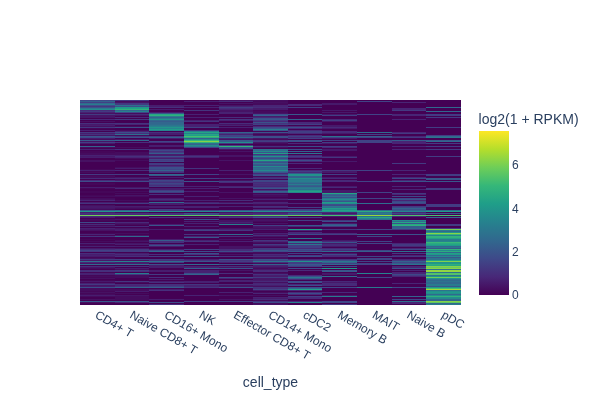

In [5]:
markers = snap.tl.marker_regions(peak_matrix, groupby="cell_type", pvalue=0.01)
snap.pl.regions(peak_matrix, groupby="cell_type", peaks=markers, interactive=False)

(chromatin-accessibility-peaks-motifs-key-takeaway-3)=
## Motif enrichment

TFs bind short sequence motifs, so a motif that is overrepresented in the peaks of a cell type points to TFs that regulate it.
We test the marker peaks of each cell type for the TF motifs of CIS-BP {cite:p}`atacpm:weirauch2014`, keeping the most informative motif per TF, against the marker peaks of all cell types.

In [6]:
fasta = ln.Artifact.get(key="chromatin_accessibility/gencode_v41_GRCh38.fa").cache()
motif_file = ln.Artifact.get(key="chromatin_accessibility/cisBP_human.meme").cache()
cis_bp = {}
for motif in snap.read_motifs(str(motif_file)):
    motif.id = motif.name = motif.id.split("+")[0]
    if (
        motif.name not in cis_bp
        or motif.info_content() > cis_bp[motif.name].info_content()
    ):
        cis_bp[motif.name] = motif
enrichment = snap.tl.motif_enrichment(
    motifs=list(cis_bp.values()), regions=markers, genome_fasta=fasta
)

2026-09-29 17:43:34 - INFO - Fetching 36831 sequences ...


2026-09-29 17:43:34 - INFO - Computing enrichment ...


  0%|          | 0/1165 [00:00<?, ?it/s]

  0%|          | 2/1165 [00:00<01:18, 14.80it/s]

  0%|          | 4/1165 [00:00<01:09, 16.64it/s]

...

 99%|█████████▉| 1157/1165 [01:01<00:00, 13.19it/s]

100%|█████████▉| 1160/1165 [01:01<00:00, 14.30it/s]

100%|█████████▉| 1162/1165 [01:01<00:00, 14.09it/s]

100%|█████████▉| 1164/1165 [01:02<00:00, 13.05it/s]

100%|██████████| 1165/1165 [01:02<00:00, 18.75it/s]

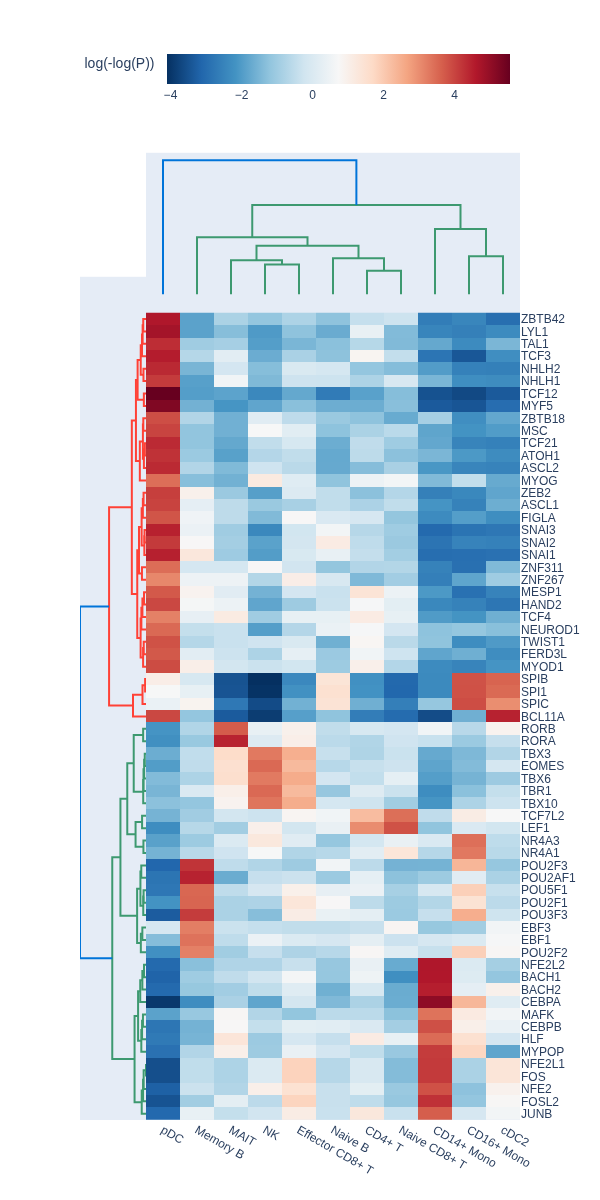

In [7]:
snap.pl.motif_enrichment(enrichment, max_fdr=1e-20, height=1200, interactive=False)

The motifs enriched in each cell type match its known regulators: CEBP and AP-1 motifs in CD14+ monocytes, PU.1 (SPI1) motifs in CD16+ monocytes and cDC2, and NR4A motifs in CD16+ monocytes.
NK and effector CD8+ T cells are enriched for the T-box motif of EOMES and T-bet, naive T cells for the motif of LEF1 and TCF7, and MAIT cells for the ROR motif.
B cells are enriched for EBF1 and octamer motifs, which OCT2 binds together with its coactivator OBF1 (POU2AF1), and pDCs for E-box motifs, which include the motif of TCF4.
TFs of one family share nearly identical motifs, so enrichment points to a family rather than a single TF, and the expression of its members shows which of them is active.

Motif enrichment describes groups of peaks, not single cells.
chromVAR estimates the accessibility of each motif in every cell against background peaks with matching GC content and accessibility {cite:p}`atacpm:schep2017chromvar`, but its Python port, pychromVAR, has neither been published nor updated since 2023, so we do not use it here.

We store the peak matrix for the [gene regulatory network chapter](gene_regulatory_networks_atac.ipynb).

In [8]:
ln.Artifact.from_anndata(
    peak_matrix,
    key="chromatin_accessibility/pbmc10k_peaks.h5ad",
    description="PBMC 10k multiome peak matrix of cell type-specific peaks",
).save()

→ returning artifact with same hash: Artifact(uid='cVC0NFWH4GNmOHGK0000', key='chromatin_accessibility/pbmc10k_peaks.h5ad', description='PBMC 10k multiome peak matrix of cell type-specific peaks', suffix='.h5ad', kind='dataset', otype='AnnData', size=589440702, hash='LJhJVBzFJWyHV2LgZbZpG-', n_files=None, n_observations=9255, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=171, schema_id=None, created_by_id=2, created_at=2026-09-29 15:34:35 UTC, is_locked=False, version_tag=None, is_latest=True); to track this artifact as an input, use: ln.Artifact.get()


Artifact(uid='cVC0NFWH4GNmOHGK0000', key='chromatin_accessibility/pbmc10k_peaks.h5ad', description='PBMC 10k multiome peak matrix of cell type-specific peaks', suffix='.h5ad', kind='dataset', otype='AnnData', size=589440702, hash='LJhJVBzFJWyHV2LgZbZpG-', n_files=None, n_observations=9255, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=171, schema_id=None, created_by_id=2, created_at=2026-09-29 15:34:35 UTC, is_locked=False, version_tag=None, is_latest=True)

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Lukas Heumos